<a href="https://colab.research.google.com/github/pt2y1003/ColumbiaDS/blob/main/VaRNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Deep Sets to predict credit ES(99%) allocation ratios (alpha_i)
# Teacher: conditional expected loss in the tail (ES band)
# Model: 1-factor Gaussian copula (asset correlation via rho_i)
# Inputs per obligor: (logEAD, logitPD, rho)
# Output: alpha_i (softmax, sum=1) -- relative allocation is enough
# ============================================================

import math
import random
from dataclasses import dataclass, field
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# -----------------------------
# Utilities
# -----------------------------
def logit(p: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def inv_norm_cdf(p: np.ndarray) -> np.ndarray:
    # Phi^{-1}(p) = sqrt(2)*erfinv(2p-1) using torch (no scipy needed)
    t = torch.tensor(p, dtype=torch.float64)
    z = math.sqrt(2.0) * torch.erfinv(2.0 * t - 1.0)
    return z.cpu().numpy()

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# -----------------------------
# Teacher generator (MC) for ES allocation
# -----------------------------
@dataclass
class TeacherConfig:
    es_q: float = 0.99           # ES level: tail is top (1-es_q) fraction
    lgd: float = 0.6             # constant LGD
    mc_paths: int = 8000         # MC scenarios per portfolio (Colab-friendly)
    min_tail_scenarios: int = 200  # ensure enough tail samples even when M small

def simulate_alpha_es_tail(
    ead: np.ndarray,
    pd: np.ndarray,
    rho: np.ndarray,
    cfg: TeacherConfig
) -> np.ndarray:
    """
    1-factor Gaussian copula:
      Y_i = sqrt(rho_i)*Z + sqrt(1-rho_i)*eps_i
      default if Y_i < Phi^{-1}(PD_i)
      Loss_i = EAD_i * LGD * 1{default}
    Teacher alpha (ES allocation ratio):
      alpha_i = E[Loss_i | L >= VaR_q] / sum_j E[Loss_j | L >= VaR_q]
              = (mean loss_i over tail) normalized to sum=1
    """
    n = ead.shape[0]
    M = cfg.mc_paths

    # thresholds
    thr = inv_norm_cdf(pd)  # (n,)

    # draw common factor and idiosyncratic shocks
    Z = np.random.randn(M, 1)                 # (M,1)
    E = np.random.randn(M, n)                 # (M,n)

    sqrt_rho = np.sqrt(rho).reshape(1, n)
    sqrt_1mr = np.sqrt(1.0 - rho).reshape(1, n)

    Y = sqrt_rho * Z + sqrt_1mr * E           # (M,n)
    D = (Y < thr.reshape(1, n))               # (M,n) bool

    loss_i = (ead.reshape(1, n) * cfg.lgd) * D.astype(np.float64)  # (M,n)
    L = loss_i.sum(axis=1)                                           # (M,)

    # Tail set for ES: L >= VaR_q
    q = cfg.es_q
    idx_var = int(np.floor(q * (M - 1)))
    L_sorted = np.sort(L)
    var_q = L_sorted[idx_var]

    tail = (L >= var_q)

    # If tail is too thin due to discreteness / tiny M, enforce at least K tail scenarios
    if tail.sum() < cfg.min_tail_scenarios:
        K = min(M, cfg.min_tail_scenarios)
        top_idx = np.argpartition(L, -K)[-K:]
        tail_mask = np.zeros(M, dtype=bool)
        tail_mask[top_idx] = True
        tail = tail_mask

    loss_i_tail = loss_i[tail]        # (T,n)
    if loss_i_tail.size == 0:
        return np.ones(n) / n

    alpha = loss_i_tail.mean(axis=0)  # E[Loss_i | tail]
    s = alpha.sum()
    if s <= 0:
        return np.ones(n) / n

    alpha = (alpha / s).astype(np.float32)
    return alpha


# -----------------------------
# Portfolio sampler
# -----------------------------
@dataclass
class PortfolioSamplerConfig:
    n_min: int = 50
    n_max: int = 400
    # EAD: lognormal-ish
    log_ead_mu: float = 2.0
    log_ead_sigma: float = 1.0
    # PD: logit-normal
    pd_logit_mu: float = -4.0
    pd_logit_sigma: float = 1.0
    # rho: Beta -> [rho_min, rho_max]
    rho_a: float = 2.0
    rho_b: float = 10.0
    rho_min: float = 0.01
    rho_max: float = 0.40

def sample_portfolio(cfg: PortfolioSamplerConfig) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = np.random.randint(cfg.n_min, cfg.n_max + 1)

    log_ead = np.random.normal(cfg.log_ead_mu, cfg.log_ead_sigma, size=n)
    ead = np.exp(log_ead).astype(np.float64)

    pd_logit = np.random.normal(cfg.pd_logit_mu, cfg.pd_logit_sigma, size=n)
    pd = (1.0 / (1.0 + np.exp(-pd_logit))).astype(np.float64)
    pd = np.clip(pd, 1e-5, 0.3)

    rho_raw = np.random.beta(cfg.rho_a, cfg.rho_b, size=n)
    rho = (cfg.rho_min + (cfg.rho_max - cfg.rho_min) * rho_raw).astype(np.float64)

    return ead, pd, rho


# -----------------------------
# Deep Sets model for alpha
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int, out_dim: int, depth: int = 2, dropout: float = 0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepSetsAlpha(nn.Module):
    def __init__(self, x_dim: int = 3, h_dim: int = 64, g_dim: int = 64):
        super().__init__()
        self.phi = MLP(x_dim, hidden=h_dim, out_dim=h_dim, depth=2, dropout=0.0)
        # use global summaries: mean/max/var
        self.psi = MLP(h_dim + 3*h_dim, hidden=g_dim, out_dim=1, depth=2, dropout=0.0)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        """
        x: (B, N, x_dim) padded
        mask: (B, N) boolean; True for valid, False for pad
        """
        B, N, _ = x.shape
        h = self.phi(x)  # (B,N,h_dim)

        m = mask.unsqueeze(-1).float()  # (B,N,1)
        h_m = h * m
        denom = m.sum(dim=1).clamp_min(1.0)  # (B,1)

        g_mean = h_m.sum(dim=1) / denom

        h_for_max = h.clone()
        h_for_max[mask == 0] = -1e9
        g_max = h_for_max.max(dim=1).values

        g_sqmean = (h_m.pow(2).sum(dim=1) / denom)
        g_var = (g_sqmean - g_mean.pow(2)).clamp_min(0.0)

        g = torch.cat([g_mean, g_max, g_var], dim=-1)  # (B,3*h_dim)
        g_b = g.unsqueeze(1).expand(B, N, g.shape[-1])

        z = torch.cat([h, g_b], dim=-1)
        s = self.psi(z).squeeze(-1)     # (B,N)

        s = s.masked_fill(mask == 0, -1e9)
        alpha = F.softmax(s, dim=1)
        return alpha


# -----------------------------
# Batch maker (variable N -> padded tensors)
# -----------------------------
def make_batch(portfolios, device="cpu"):
    B = len(portfolios)
    Nmax = max(p["x"].shape[0] for p in portfolios)

    x = torch.zeros(B, Nmax, 3, dtype=torch.float32)
    y = torch.zeros(B, Nmax, dtype=torch.float32)
    mask = torch.zeros(B, Nmax, dtype=torch.bool)

    for b, p in enumerate(portfolios):
        n = p["x"].shape[0]
        x[b, :n] = torch.from_numpy(p["x"])
        y[b, :n] = torch.from_numpy(p["alpha"])
        mask[b, :n] = True

    return x.to(device), y.to(device), mask.to(device)


# -----------------------------
# Training
# -----------------------------
@dataclass
class TrainConfig:
    device: str = "cpu"
    steps: int = 3000
    batch_size: int = 16
    lr: float = 3e-4

    sampler_cfg: PortfolioSamplerConfig = field(default_factory=PortfolioSamplerConfig)
    teacher_cfg: TeacherConfig = field(default_factory=lambda: TeacherConfig(mc_paths=8000, es_q=0.99))

    # loss weights (focus on concentration)
    topk: int = 20
    topk_weight: float = 3.0

def loss_alpha(pred_alpha: torch.Tensor, true_alpha: torch.Tensor, mask: torch.Tensor,
               topk: int = 20, topk_weight: float = 3.0):
    # base: Huber on valid names
    diff = pred_alpha - true_alpha
    base = F.smooth_l1_loss(diff[mask], torch.zeros_like(diff[mask]))

    # top-k emphasis per portfolio
    B, _ = true_alpha.shape
    extra_terms = []
    for b in range(B):
        mb = mask[b]
        tb = true_alpha[b][mb]
        pb = pred_alpha[b][mb]
        if tb.numel() <= 1:
            continue
        k = min(topk, tb.numel())
        idx = torch.topk(tb, k=k, largest=True).indices
        extra_terms.append(F.smooth_l1_loss(pb[idx], tb[idx]))
    extra = torch.stack(extra_terms).mean() if extra_terms else torch.tensor(0.0, device=true_alpha.device)

    return base + topk_weight * extra

def generate_one_portfolio(sampler_cfg: PortfolioSamplerConfig, teacher_cfg: TeacherConfig):
    ead, pd, rho = sample_portfolio(sampler_cfg)
    alpha = simulate_alpha_es_tail(ead, pd, rho, teacher_cfg)

    x = np.stack([
        np.log(ead).astype(np.float32),
        logit(pd).astype(np.float32),
        rho.astype(np.float32)
    ], axis=1)

    return {"x": x, "alpha": alpha}

def train_deepsets_alpha(cfg: TrainConfig):
    device = cfg.device
    model = DeepSetsAlpha(x_dim=3, h_dim=64, g_dim=64).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)

    model.train()
    for step in range(1, cfg.steps + 1):
        portfolios = [generate_one_portfolio(cfg.sampler_cfg, cfg.teacher_cfg) for _ in range(cfg.batch_size)]
        x, y, mask = make_batch(portfolios, device=device)

        pred = model(x, mask)
        loss = loss_alpha(pred, y, mask, topk=cfg.topk, topk_weight=cfg.topk_weight)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % 100 == 0:
            with torch.no_grad():
                pv = pred[mask].detach().cpu().numpy()
                tv = y[mask].detach().cpu().numpy()
                corr = np.corrcoef(pv, tv)[0, 1] if pv.size > 5 else np.nan
            print(f"step={step:4d} loss={loss.item():.6f} corr(valid)={corr:.4f}")

    return model


# -----------------------------
# Inference helper
# -----------------------------
@torch.no_grad()
def predict_alpha(model: nn.Module, ead: np.ndarray, pd: np.ndarray, rho: np.ndarray, device="cpu") -> np.ndarray:
    x = np.stack([
        np.log(ead).astype(np.float32),
        logit(pd).astype(np.float32),
        rho.astype(np.float32)
    ], axis=1)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)  # (1,N,3)
    mask = torch.ones(1, x.shape[0], dtype=torch.bool).to(device)
    model.eval()
    alpha = model(x_t, mask).squeeze(0).cpu().numpy()
    return alpha


if __name__ == "__main__":
    set_seed(42)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Colabでまず動作確認しやすい設定
    cfg = TrainConfig(
        device=device,
        steps=1000,          # まずは1000で挙動確認。精度を上げるなら5000〜20000
        batch_size=8,        # 重ければ 4〜8
        lr=3e-4,
        teacher_cfg=TeacherConfig(es_q=0.99, mc_paths=8000, lgd=0.6, min_tail_scenarios=200),
    )

    model = train_deepsets_alpha(cfg)

    # sanity check
    ead, pd, rho = sample_portfolio(cfg.sampler_cfg)
    alpha_hat = predict_alpha(model, ead, pd, rho, device=device)

    print("alpha_hat sum =", float(alpha_hat.sum()), "min/max =", float(alpha_hat.min()), float(alpha_hat.max()))


step= 100 loss=0.000402 corr(valid)=0.9562
step= 200 loss=0.000316 corr(valid)=0.9811
step= 300 loss=0.000525 corr(valid)=0.9688
step= 400 loss=0.000109 corr(valid)=0.9903
step= 500 loss=0.000204 corr(valid)=0.9898
step= 600 loss=0.000193 corr(valid)=0.9844
step= 700 loss=0.000108 corr(valid)=0.9768
step= 800 loss=0.000272 corr(valid)=0.9701
step= 900 loss=0.000094 corr(valid)=0.9853
step=1000 loss=0.000413 corr(valid)=0.9804
alpha_hat sum = 1.0 min/max = 7.26140133338049e-05 0.10677917301654816


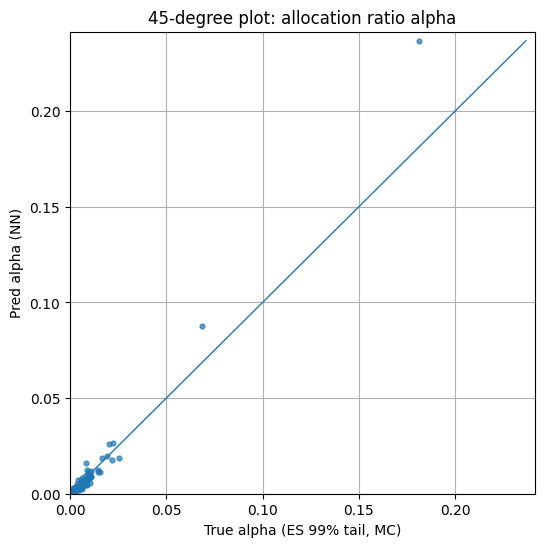

sum true: 0.9999999403953552 sum pred: 0.9999998807907104
corr: 0.9925475708961351
Top-20 Jaccard: 0.6666666666666666


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) テスト用ポートフォリオを「訓練レンジ内」で用意（同じSamplerから1本サンプル） ---
test_ead, test_pd, test_rho = sample_portfolio(cfg.sampler_cfg)

# --- 2) "真値"（教師）を高精度MCで作る：ES(99%) tail allocation ratio ---
# ここだけ mc_paths を大きくして、真値のノイズを減らします（重ければ 20000 程度でもOK）
teacher_cfg_test = TeacherConfig(
    es_q=0.99,
    lgd=cfg.teacher_cfg.lgd,
    mc_paths=50000,              # 例：5万。重ければ 20000 に下げてOK
    min_tail_scenarios=500
)
true_alpha = simulate_alpha_es_tail(test_ead, test_pd, test_rho, teacher_cfg_test)

# --- 3) 予測alpha ---
pred_alpha = predict_alpha(model, test_ead, test_pd, test_rho, device=cfg.device)

# --- 4) 45度線プロット（真値 vs 予測） ---
# 見やすさのため、極小αは除外 or 上位のみ表示も可。まずは全点表示します。
x = true_alpha
y = pred_alpha

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=12, alpha=0.7)

# 45度線
mx = max(x.max(), y.max())
plt.plot([0, mx], [0, mx], linewidth=1)

plt.xlabel("True alpha (ES 99% tail, MC)")
plt.ylabel("Pred alpha (NN)")
plt.title("45-degree plot: allocation ratio alpha")
plt.xlim(0, mx * 1.02)
plt.ylim(0, mx * 1.02)
plt.grid(True)
plt.show()

# --- 5) 参考：簡単な指標も出しておく（相関・上位K一致など） ---
corr = np.corrcoef(x, y)[0, 1] if x.size > 5 else np.nan
print("sum true:", float(x.sum()), "sum pred:", float(y.sum()))
print("corr:", float(corr))

# 上位Kの一致（相対比較が目的なら便利）
K = min(20, len(x))
top_true = set(np.argsort(-x)[:K].tolist())
top_pred = set(np.argsort(-y)[:K].tolist())
jaccard = len(top_true & top_pred) / len(top_true | top_pred)
print(f"Top-{K} Jaccard:", jaccard)

In [3]:
# 方法1（いちばん分かりやすい）
N = len(test_ead)
print("Test portfolio N =", N)

# 方法2
print("Test portfolio N =", test_pd.shape[0])

# 方法3
print("Test portfolio N =", test_rho.shape[0])

# 方法4（alphaベクトルから）
print("Test portfolio N =", len(true_alpha))


Test portfolio N = 317
Test portfolio N = 317
Test portfolio N = 317
Test portfolio N = 317
